# Smart Spend

Smart spend adalah website berbasis AI yang digunakan untuk mengatur budgeting para pengguna. Ide project ini dibuat karena kurangnya orang dalam mengatur keuangan sehingga keadaan keuangan menjadi boncos. dengan adanya website berbasis AI ini diharapkan orang orang bisa mengatur budget sesuai dengan keadaan keuangan sekaligus rekomendasi dari Smart Spend

<hr>

Pembuatan Model Klasifikasi untuk Chatbot




# Gathering Data

Import semua library

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

Import Dataset

In [21]:
url = "https://drive.google.com/uc?export=download&id=1n7t9XudgUGaJkETkJaSJAPSvvRE7VMOF"
df = pd.read_csv(url)
df.head()

,id,provinsi,klasifikasi_wilayah,jenis_kelamin,usia,pendidikan_terakhir,status_pekerjaan,status_pernikahan,jumlah_tanggungan,pendapatan_bulanan,...,pengeluaran_kesehatan,pengeluaran_pendidikan,pengeluaran_transportasi,pengeluaran_komunikasi,pengeluaran_hiburan_rekreasi,cicilan_hutang,tabungan_bulanan,rasio_tabungan_persen,skor_literasi_keuangan,label_rekomendasi
0,1160,DKI Jakarta,Perkotaan,Perempuan,25.0,SMP,Buruh/Pekerja Harian,Menikah,1.0,3350000.0,...,129000.0,116000.0,162000.0,100000.0,98000.0,0.0,827000.0,24.7,45.6,Keuangan Sehat
1,1824,DKI Jakarta,Perkotaan,Perempuan,23.0,SD,PNS/ASN,Menikah,2.0,9500000.0,...,695000.0,681000.0,1129000.0,341000.0,272000.0,1686000.0,1347000.0,14.2,49.1,Cukup Baik
2,979,Sumatera Selatan,Perkotaan,Laki-laki,59.0,Diploma,PNS/ASN,Menikah,NaN,6500000.0,...,236000.0,271000.0,441000.0,170000.0,186000.0,0.0,1876000.0,28.9,NaN,Keuangan Sehat
3,760,Bali,Perkotaan,Perempuan,47.0,SD,Buruh/Pekerja Harian,Menikah,2.0,1700000.0,...,58000.0,38000.0,86000.0,30000.0,30000.0,0.0,426000.0,25.1,32.5,Keuangan Sehat
4,875,Sumatera Selatan,Perkotaan,Laki-laki,17.0,Pascasarjana (S2/S3),Buruh/Pekerja Harian,NaN,3.0,NaN,...,93000.0,197000.0,291000.0,140000.0,141000.0,NaN,448000.0,NaN,77.3,Cukup Baik


In [22]:
df.describe(include='all')

,id,provinsi,klasifikasi_wilayah,jenis_kelamin,usia,pendidikan_terakhir,status_pekerjaan,status_pernikahan,jumlah_tanggungan,pendapatan_bulanan,...,pengeluaran_kesehatan,pengeluaran_pendidikan,pengeluaran_transportasi,pengeluaran_komunikasi,pengeluaran_hiburan_rekreasi,cicilan_hutang,tabungan_bulanan,rasio_tabungan_persen,skor_literasi_keuangan,label_rekomendasi
count,2150.000000,2150,2150,2150,2107.000000,2086,2064,2086,2043.000000,1.978000e+03,...,2.021000e+03,1.957000e+03,2.043000e+03,2.064000e+03,1978.000000,1.935000e+03,2.000000e+03,2000.000000,2043.000000,2150
unique,NaN,12,2,2,NaN,7,6,3,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,Jawa Barat,Perkotaan,Laki-laki,NaN,SMA/SMK,Karyawan Swasta,Menikah,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Keuangan Sehat
freq,NaN,418,1240,1093,NaN,764,711,1291,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1206
mean,1002.041395,NaN,NaN,NaN,35.564309,NaN,NaN,NaN,1.325991,4.195930e+06,...,1.676353e+05,1.206418e+05,2.982726e+05,1.484375e+05,125804.853387,1.942362e+05,9.058405e+05,21.490450,53.808468,NaN
std,577.341356,NaN,NaN,NaN,11.681310,NaN,NaN,NaN,1.301489,3.356503e+06,...,1.674059e+05,1.894444e+05,2.926701e+05,1.482358e+05,128346.629073,3.512631e+05,8.442213e+05,7.903261,14.825498,NaN
min,1.000000,NaN,NaN,NaN,17.000000,NaN,NaN,NaN,0.000000,5.000000e+05,...,7.000000e+03,0.000000e+00,1.300000e+04,6.000000e+03,4000.000000,0.000000e+00,4.500000e+04,8.000000,6.300000,NaN
25%,501.250000,NaN,NaN,NaN,27.000000,NaN,NaN,NaN,0.000000,1.800000e+06,...,5.200000e+04,0.000000e+00,9.800000e+04,4.700000e+04,37000.000000,0.000000e+00,3.420000e+05,14.400000,43.300000,NaN
50%,1000.500000,NaN,NaN,NaN,35.000000,NaN,NaN,NaN,1.000000,3.300000e+06,...,1.140000e+05,4.000000e+04,2.080000e+05,1.005000e+05,84000.000000,5.000000e+03,6.595000e+05,21.300000,53.900000,NaN
75%,1503.750000,NaN,NaN,NaN,44.000000,NaN,NaN,NaN,2.000000,5.700000e+06,...,2.210000e+05,1.630000e+05,3.970000e+05,1.940000e+05,168000.000000,2.475000e+05,1.192250e+06,28.400000,64.300000,NaN


# Kesimpulan
Dari dataset tersebut terdapat banyak data pendapatan dan pengeluaran setiap orangnya sekaligus pendidikan,pekerjaan,usia,jenis kelamin dan status pernikahan sehingga dengan adanya data tersebut dari user kita bisa memberikan rekomendasi yang tepat

# Assesing Data

In [23]:
df.isnull().sum()

,0
id,0
provinsi,0
klasifikasi_wilayah,0
jenis_kelamin,0
usia,43
pendidikan_terakhir,64
status_pekerjaan,86
status_pernikahan,64
jumlah_tanggungan,107
pendapatan_bulanan,172


In [24]:
df.duplicated().sum()

np.int64(12)

In [25]:
print(len(df))

2150


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2150 entries, 0 to 2149
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id                             2150 non-null   int64  
 1   provinsi                       2150 non-null   object 
 2   klasifikasi_wilayah            2150 non-null   object 
 3   jenis_kelamin                  2150 non-null   object 
 4   usia                           2107 non-null   float64
 5   pendidikan_terakhir            2086 non-null   object 
 6   status_pekerjaan               2064 non-null   object 
 7   status_pernikahan              2086 non-null   object 
 8   jumlah_tanggungan              2043 non-null   float64
 9   pendapatan_bulanan             1978 non-null   float64
 10  total_pengeluaran              2150 non-null   int64  
 11  pengeluaran_makanan_pokok      2021 non-null   float64
 12  pengeluaran_lauk_pauk          2021 non-null   f

jumlah dataset sekitar 2150 baris. terdapat banyak missing values sekaligus duplikasi data sehingga kita harus menggantinya dengan median dan modus karena jumlah dataset yang kecil  

# Cleaning Data

Mengatasi missing value dengan median dan modus dan drop duplicated data

In [27]:
df.drop_duplicates(inplace=True)

missing_values = df.isnull().sum()
less = missing_values[missing_values < 2000].index

numeric_features = df[less].select_dtypes(include=['number']).columns
df[numeric_features] = df[numeric_features].fillna(df[numeric_features].median())

kategorical_features = df[less].select_dtypes(include=['object']).columns

for column in kategorical_features:
    df[column] = df[column].fillna(df[column].mode()[0])

df.isnull().sum()

,0
id,0
provinsi,0
klasifikasi_wilayah,0
jenis_kelamin,0
usia,0
pendidikan_terakhir,0
status_pekerjaan,0
status_pernikahan,0
jumlah_tanggungan,0
pendapatan_bulanan,0


In [28]:
df.drop('id',axis=1,inplace=True)
df.head()

,provinsi,klasifikasi_wilayah,jenis_kelamin,usia,pendidikan_terakhir,status_pekerjaan,status_pernikahan,jumlah_tanggungan,pendapatan_bulanan,total_pengeluaran,...,pengeluaran_kesehatan,pengeluaran_pendidikan,pengeluaran_transportasi,pengeluaran_komunikasi,pengeluaran_hiburan_rekreasi,cicilan_hutang,tabungan_bulanan,rasio_tabungan_persen,skor_literasi_keuangan,label_rekomendasi
0,DKI Jakarta,Perkotaan,Perempuan,25.0,SMP,Buruh/Pekerja Harian,Menikah,1.0,3350000.0,2523000,...,129000.0,116000.0,162000.0,100000.0,98000.0,0.0,827000.0,24.7,45.6,Keuangan Sehat
1,DKI Jakarta,Perkotaan,Perempuan,23.0,SD,PNS/ASN,Menikah,2.0,9500000.0,8153000,...,695000.0,681000.0,1129000.0,341000.0,272000.0,1686000.0,1347000.0,14.2,49.1,Cukup Baik
2,Sumatera Selatan,Perkotaan,Laki-laki,59.0,Diploma,PNS/ASN,Menikah,1.0,6500000.0,4624000,...,236000.0,271000.0,441000.0,170000.0,186000.0,0.0,1876000.0,28.9,53.9,Keuangan Sehat
3,Bali,Perkotaan,Perempuan,47.0,SD,Buruh/Pekerja Harian,Menikah,2.0,1700000.0,1274000,...,58000.0,38000.0,86000.0,30000.0,30000.0,0.0,426000.0,25.1,32.5,Keuangan Sehat
4,Sumatera Selatan,Perkotaan,Laki-laki,17.0,Pascasarjana (S2/S3),Buruh/Pekerja Harian,Menikah,3.0,3300000.0,2802000,...,93000.0,197000.0,291000.0,140000.0,141000.0,3000.0,448000.0,21.3,77.3,Cukup Baik


# Exploratory Data Analysis

In [29]:
df.describe(include='all')

,provinsi,klasifikasi_wilayah,jenis_kelamin,usia,pendidikan_terakhir,status_pekerjaan,status_pernikahan,jumlah_tanggungan,pendapatan_bulanan,total_pengeluaran,...,pengeluaran_kesehatan,pengeluaran_pendidikan,pengeluaran_transportasi,pengeluaran_komunikasi,pengeluaran_hiburan_rekreasi,cicilan_hutang,tabungan_bulanan,rasio_tabungan_persen,skor_literasi_keuangan,label_rekomendasi
count,2138,2138,2138,2138.000000,2138,2138,2138,2138.000000,2.138000e+03,2.138000e+03,...,2.138000e+03,2.138000e+03,2.138000e+03,2.138000e+03,2138.000000,2.138000e+03,2.138000e+03,2138.000000,2138.000000,2138
unique,12,2,2,NaN,7,6,3,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,Jawa Barat,Perkotaan,Laki-laki,NaN,SMA/SMK,Karyawan Swasta,Menikah,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Keuangan Sehat
freq,417,1232,1087,NaN,823,791,1349,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1197
mean,NaN,NaN,NaN,35.538354,NaN,NaN,NaN,1.311974,4.124649e+06,3.279066e+06,...,1.644032e+05,1.137558e+05,2.940103e+05,1.466076e+05,122467.726848,1.751249e+05,8.877376e+05,21.459448,53.841581,NaN
std,NaN,NaN,NaN,11.561626,NaN,NaN,NaN,1.271500,3.231355e+06,2.674103e+06,...,1.628294e+05,1.825905e+05,2.863638e+05,1.457926e+05,123605.820322,3.386570e+05,8.165530e+05,7.622701,14.461226,NaN
min,NaN,NaN,NaN,17.000000,NaN,NaN,NaN,0.000000,5.000000e+05,3.310000e+05,...,7.000000e+03,0.000000e+00,1.300000e+04,6.000000e+03,4000.000000,0.000000e+00,4.500000e+04,8.000000,6.300000,NaN
25%,NaN,NaN,NaN,27.000000,NaN,NaN,NaN,0.000000,1.950000e+06,1.413250e+06,...,5.600000e+04,0.000000e+00,1.030000e+05,4.900000e+04,39000.000000,0.000000e+00,3.610000e+05,15.000000,44.100000,NaN
50%,NaN,NaN,NaN,35.000000,NaN,NaN,NaN,1.000000,3.300000e+06,2.576500e+06,...,1.140000e+05,4.000000e+04,2.080000e+05,1.005000e+05,84000.000000,3.000000e+03,6.590000e+05,21.300000,53.900000,NaN
75%,NaN,NaN,NaN,43.000000,NaN,NaN,NaN,2.000000,5.350000e+06,4.397500e+06,...,2.120000e+05,1.470000e+05,3.890000e+05,1.890000e+05,158000.000000,2.080000e+05,1.122000e+06,27.800000,63.900000,NaN


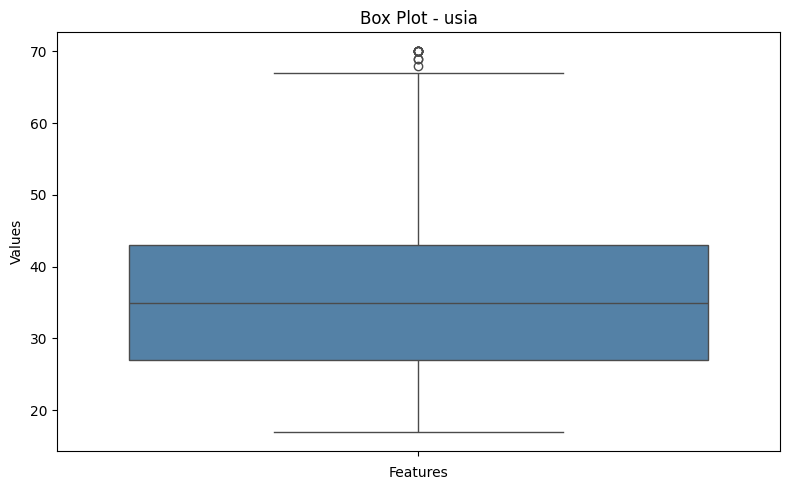

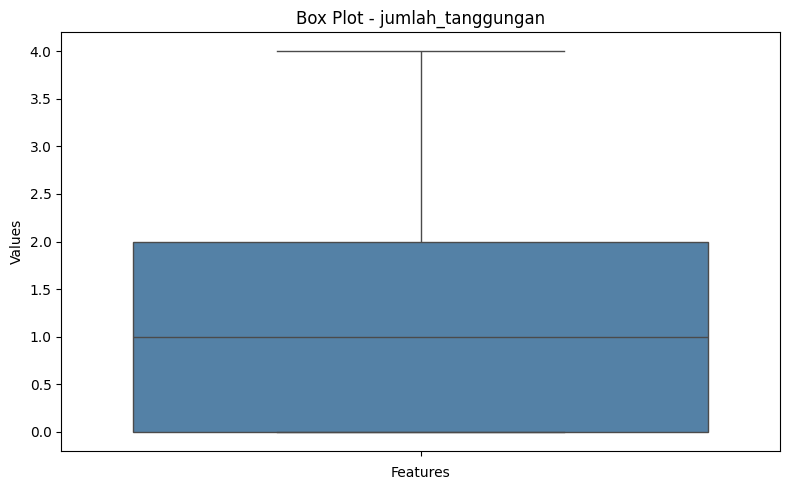

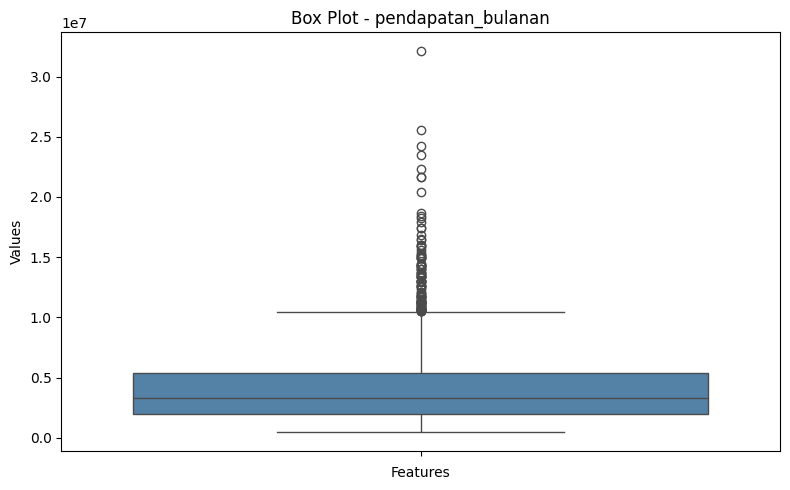

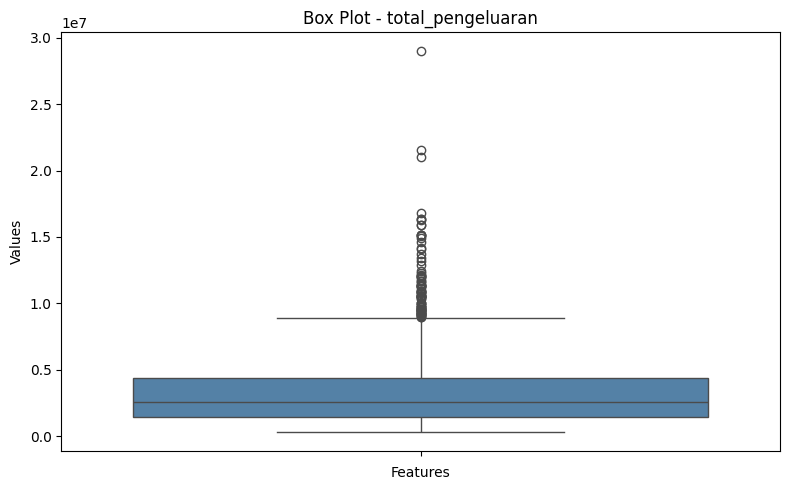

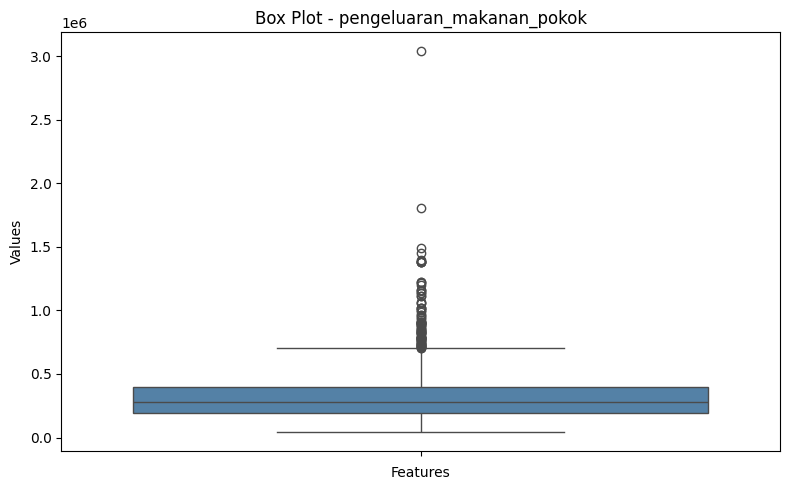

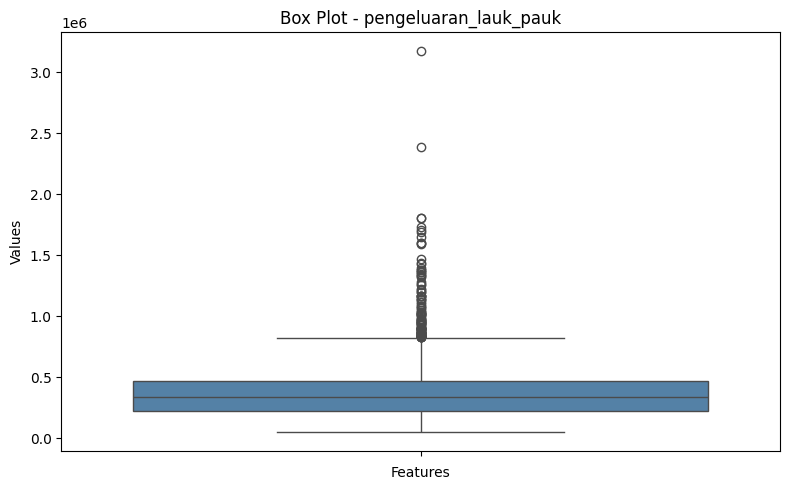

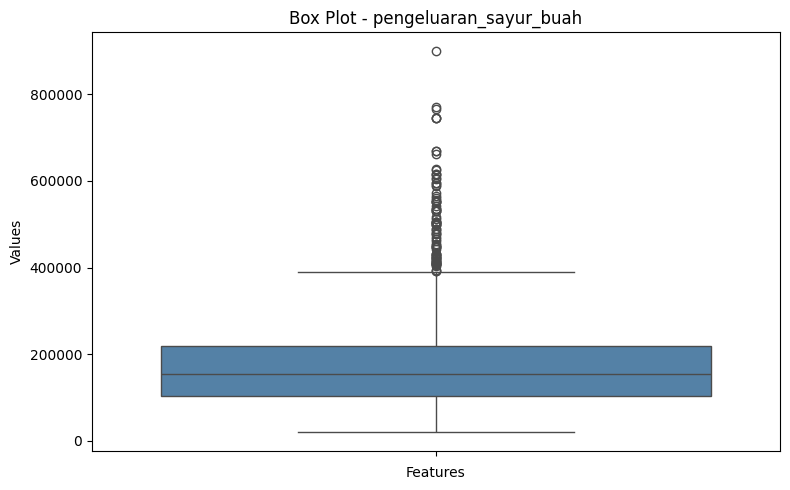

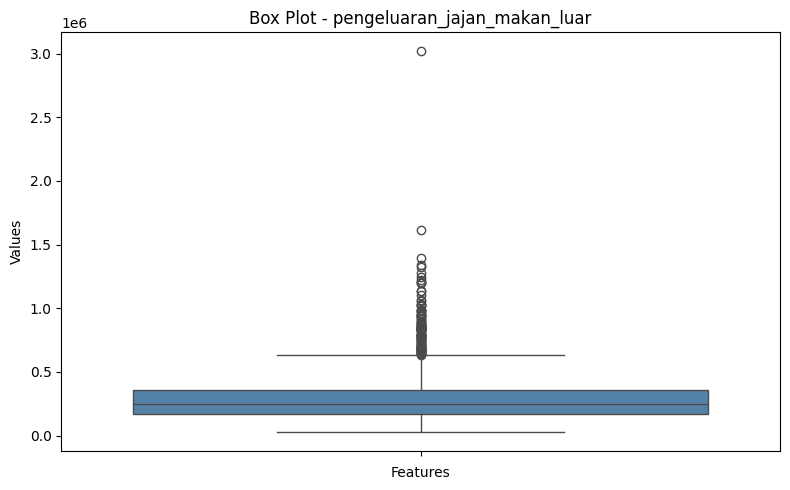

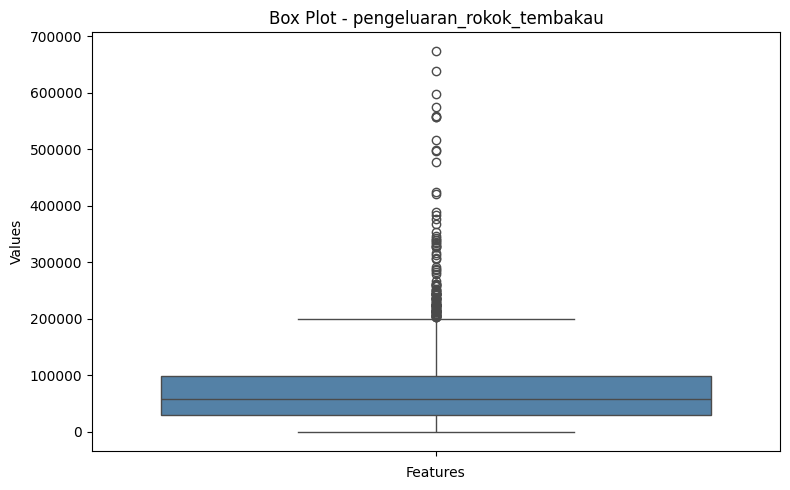

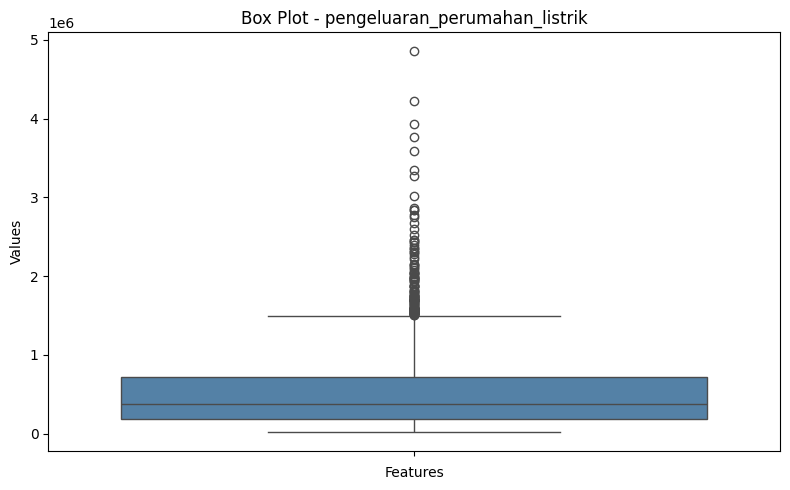

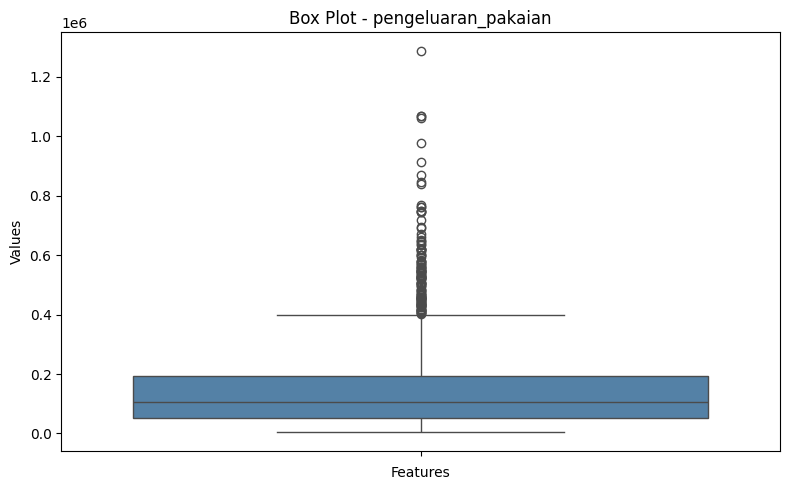

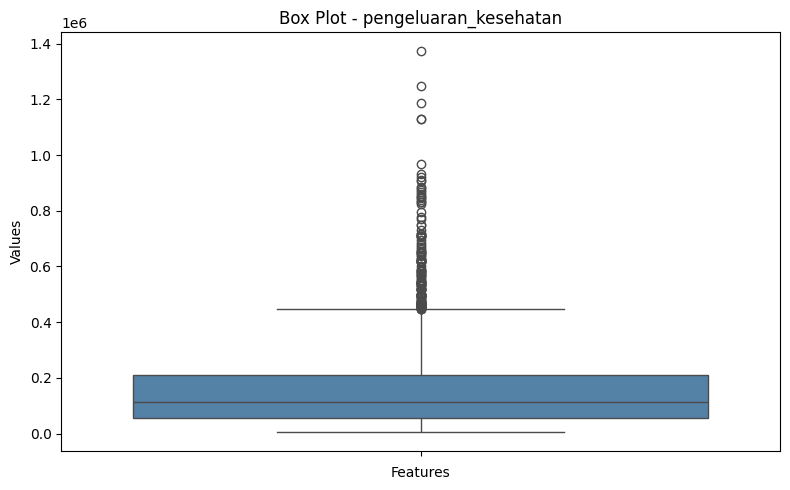

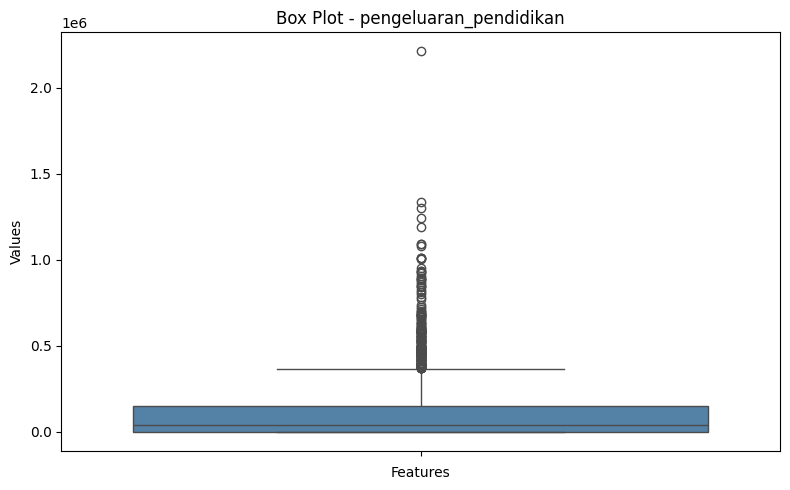

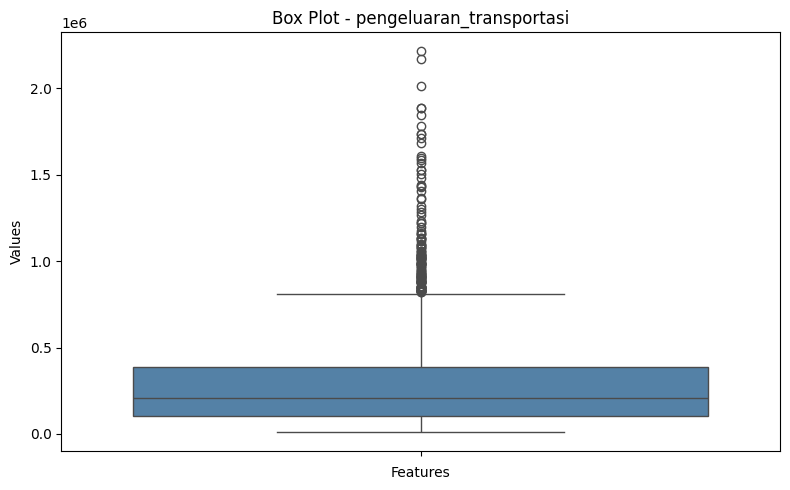

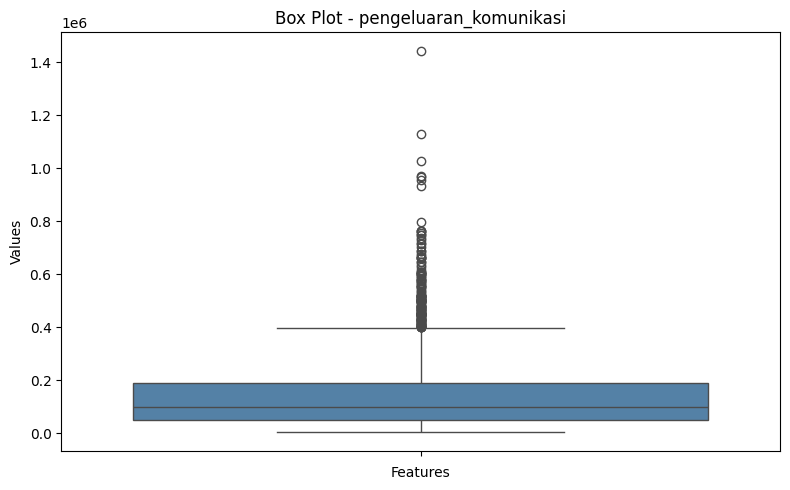

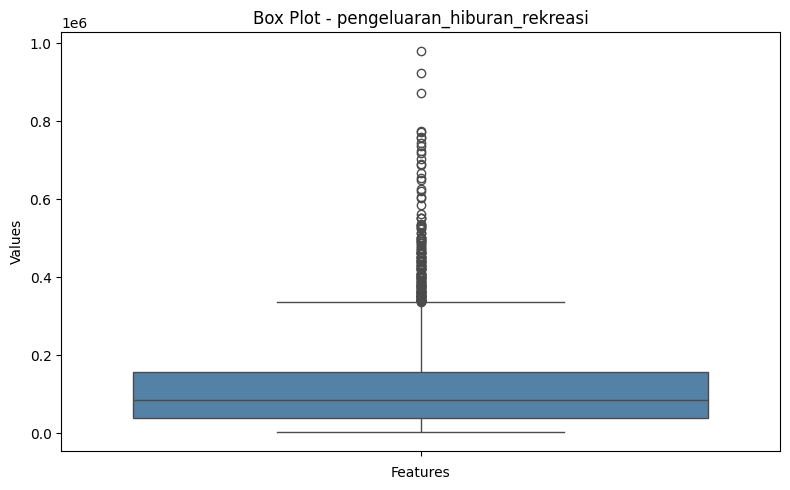

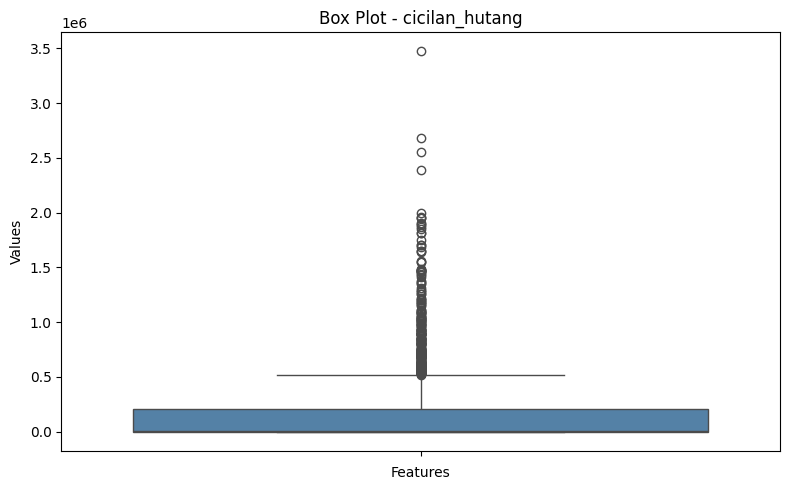

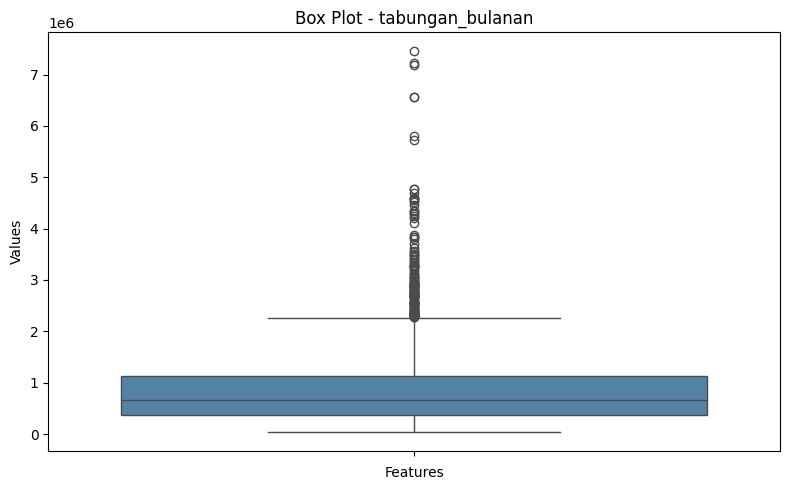

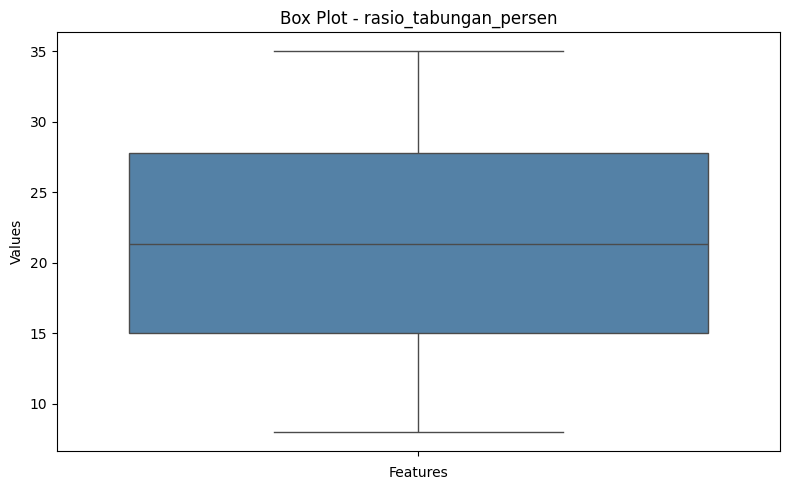

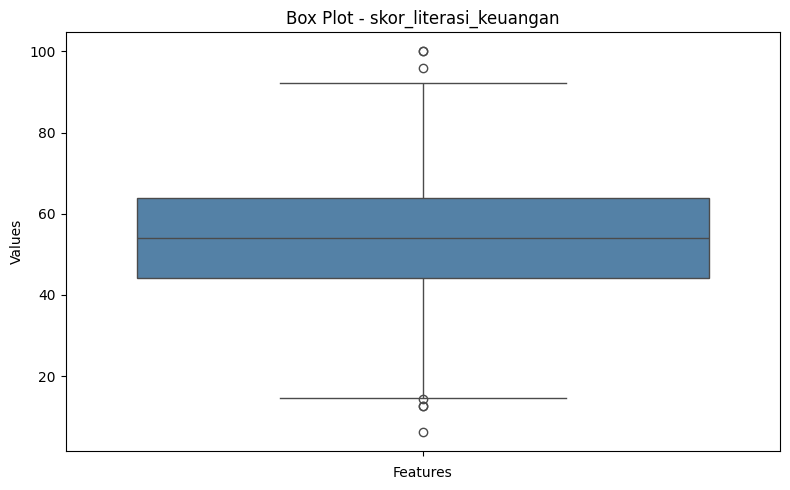

In [30]:
df_numeric = df.select_dtypes(include='number')

for column in df_numeric:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df_numeric, y=column, color='steelblue')
    plt.xlabel('Features')
    plt.ylabel('Values')
    plt.title(f'Box Plot - {column}')
    plt.tight_layout()
    plt.show()

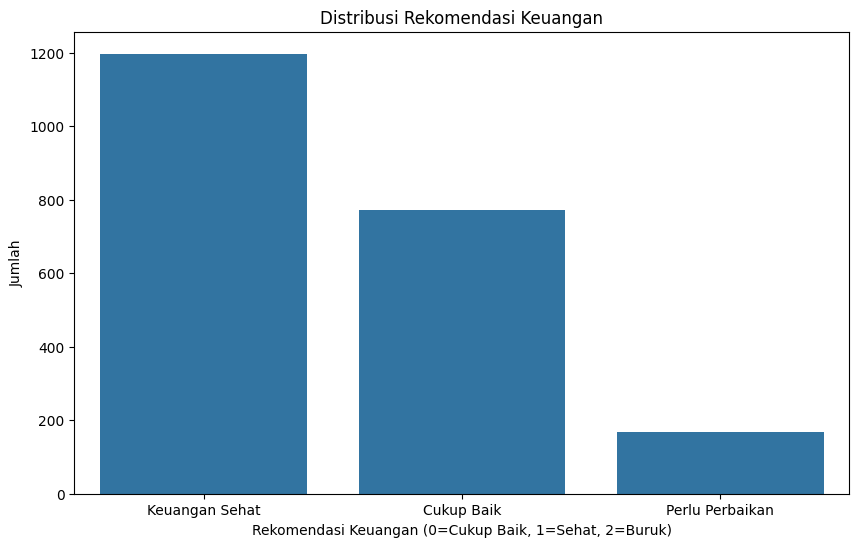

In [31]:
plt.figure(figsize=(10,6))
sns.countplot(data=df,x='label_rekomendasi')
plt.xlabel('Rekomendasi Keuangan (0=Cukup Baik, 1=Sehat, 2=Buruk)')
plt.ylabel('Jumlah')
plt.title('Distribusi Rekomendasi Keuangan')
plt.show()

# Kesimpulan
terdapat outlier dari visualisasi boxplot sekaligus terjadi imbalance dataset


# Explanatory Data Analysis

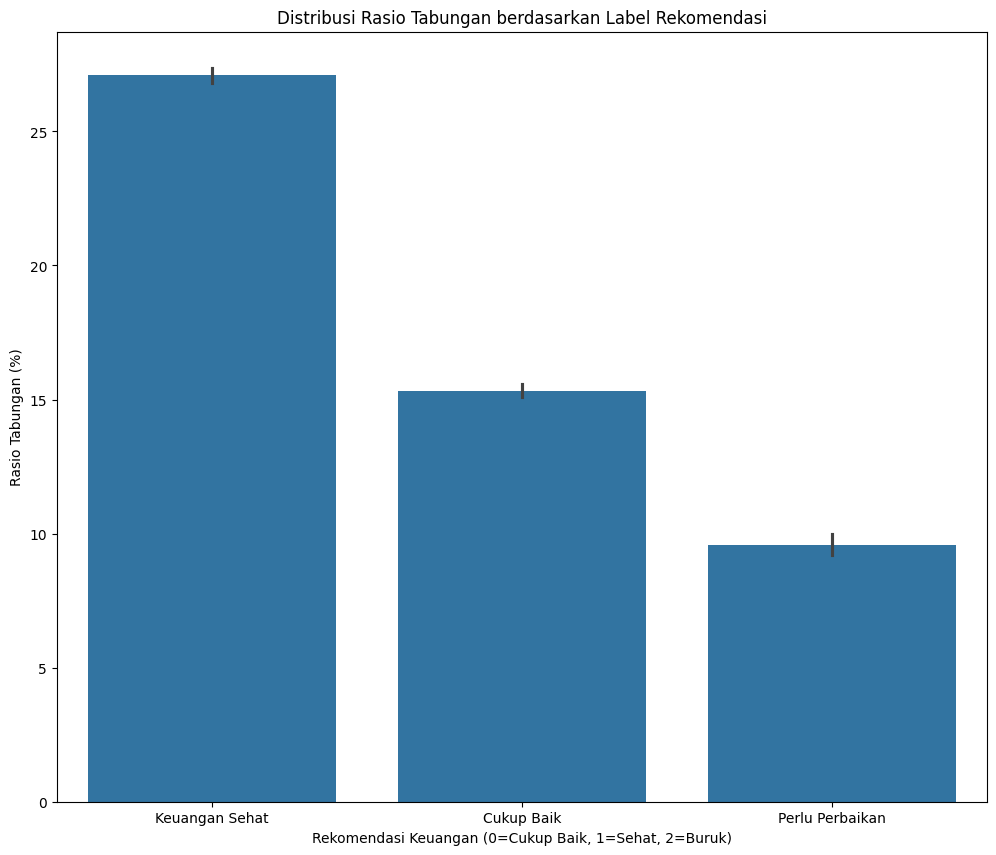

In [32]:
plt.figure(figsize=(12,10))
sns.barplot(data=df,x='label_rekomendasi',y='rasio_tabungan_persen')
plt.xlabel('Rekomendasi Keuangan (0=Cukup Baik, 1=Sehat, 2=Buruk)')
plt.ylabel('Rasio Tabungan (%)')
plt.title('Distribusi Rasio Tabungan berdasarkan Label Rekomendasi')
plt.show()

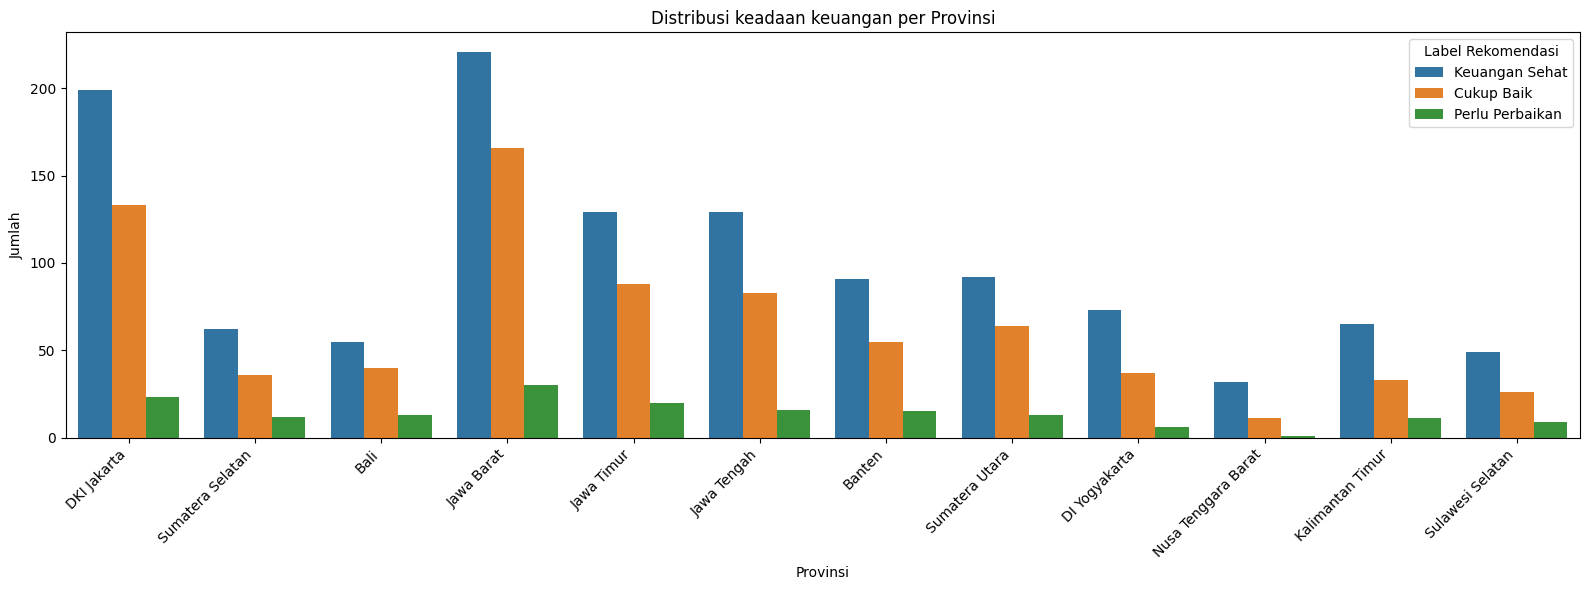

In [33]:
plt.figure(figsize=(16, 6))
sns.countplot(data=df, x='provinsi', hue='label_rekomendasi')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Provinsi')
plt.ylabel('Jumlah')
plt.title('Distribusi keadaan keuangan per Provinsi')
plt.legend(title='Label Rekomendasi')
plt.tight_layout()
plt.show()

# Kesimpulan

- semakin sehat keuangan semakin tinggi juga rasio tabungan
- di setiap daerah semakin tinggi kondisi keuangan sehat semakin tinggi juga kondisi keuangan perlu perbaikan

# Feature Engineering

In [34]:
categorical_features=df.select_dtypes(include='object').columns

label_encoder=LabelEncoder()
for column in categorical_features:
    df[column]=label_encoder.fit_transform(df[column])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2138 entries, 0 to 2149
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   provinsi                       2138 non-null   int64  
 1   klasifikasi_wilayah            2138 non-null   int64  
 2   jenis_kelamin                  2138 non-null   int64  
 3   usia                           2138 non-null   float64
 4   pendidikan_terakhir            2138 non-null   int64  
 5   status_pekerjaan               2138 non-null   int64  
 6   status_pernikahan              2138 non-null   int64  
 7   jumlah_tanggungan              2138 non-null   float64
 8   pendapatan_bulanan             2138 non-null   float64
 9   total_pengeluaran              2138 non-null   int64  
 10  pengeluaran_makanan_pokok      2138 non-null   float64
 11  pengeluaran_lauk_pauk          2138 non-null   float64
 12  pengeluaran_sayur_buah         2138 non-null   float6

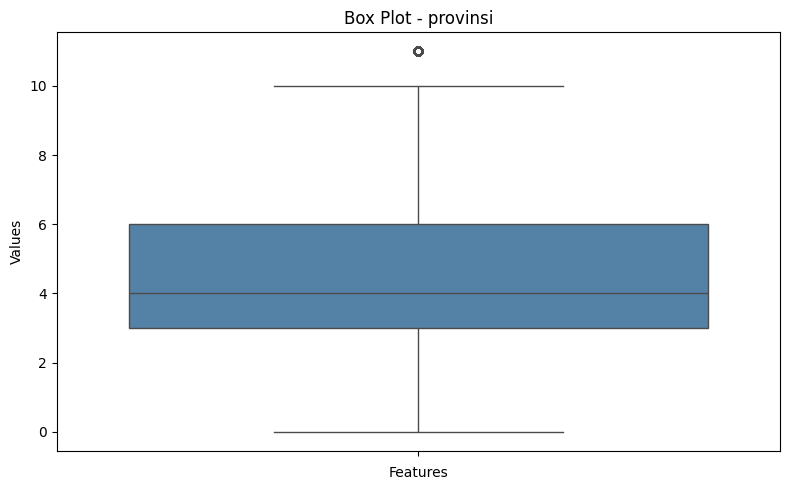

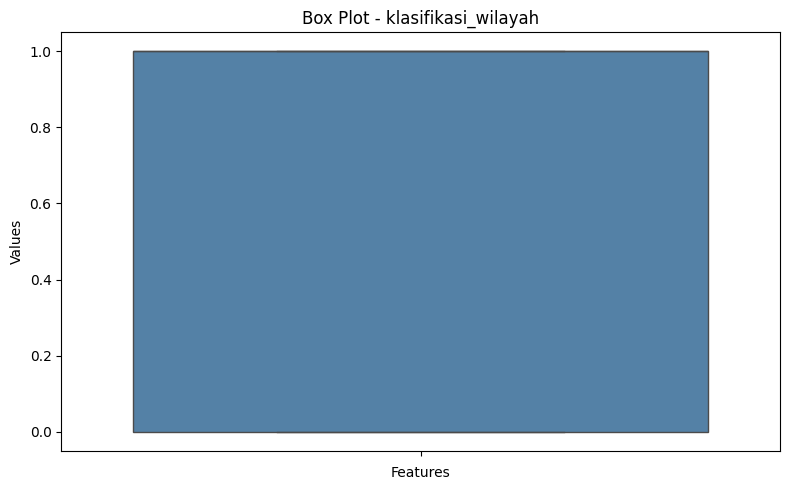

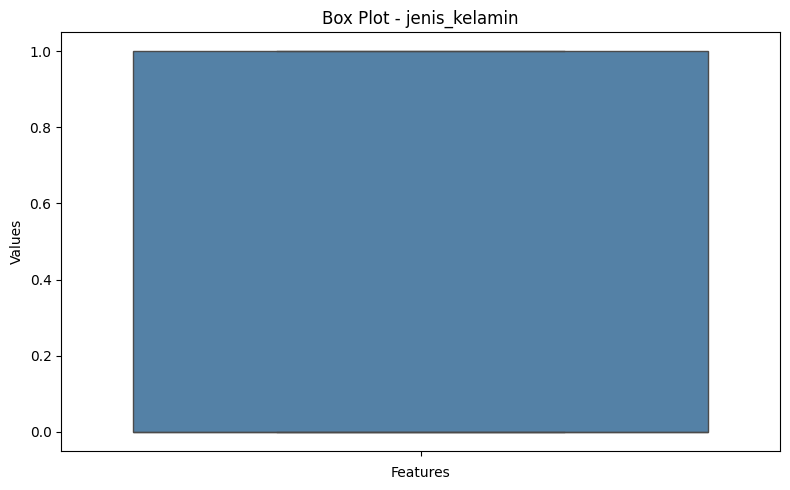

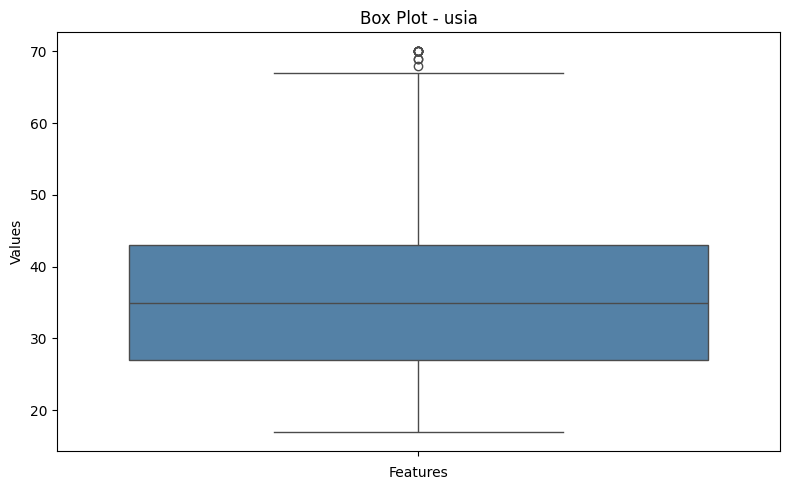

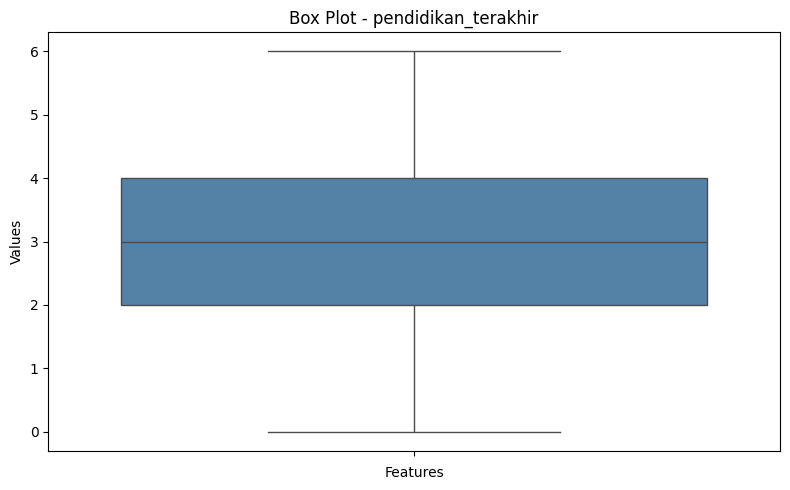

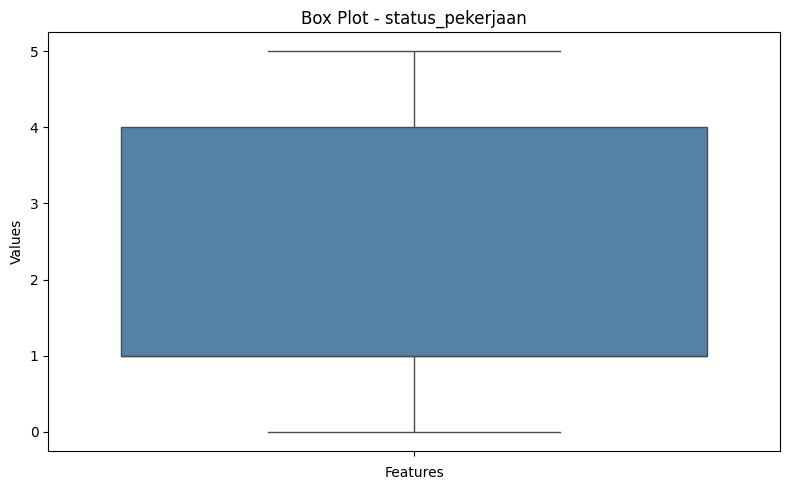

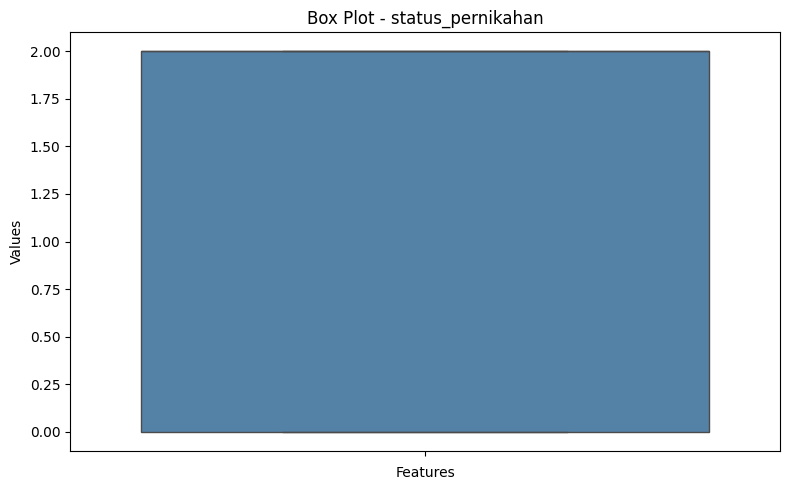

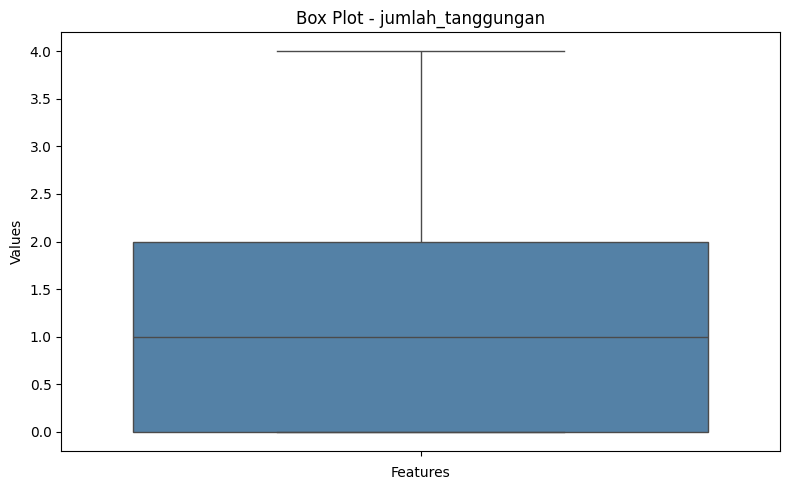

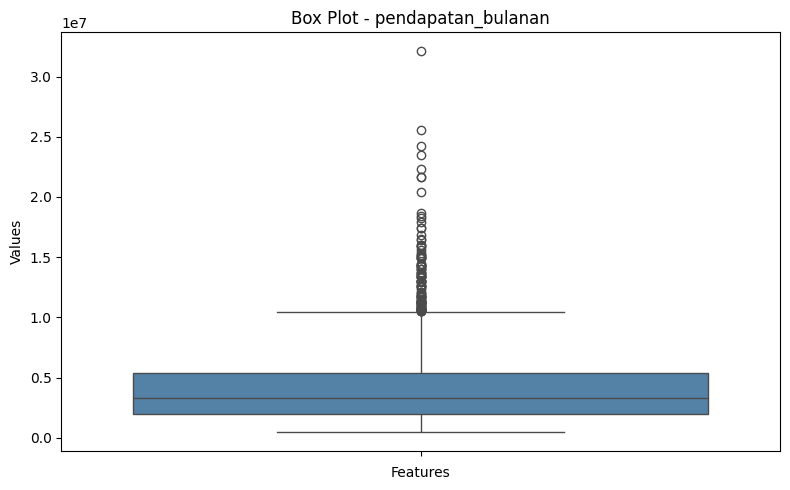

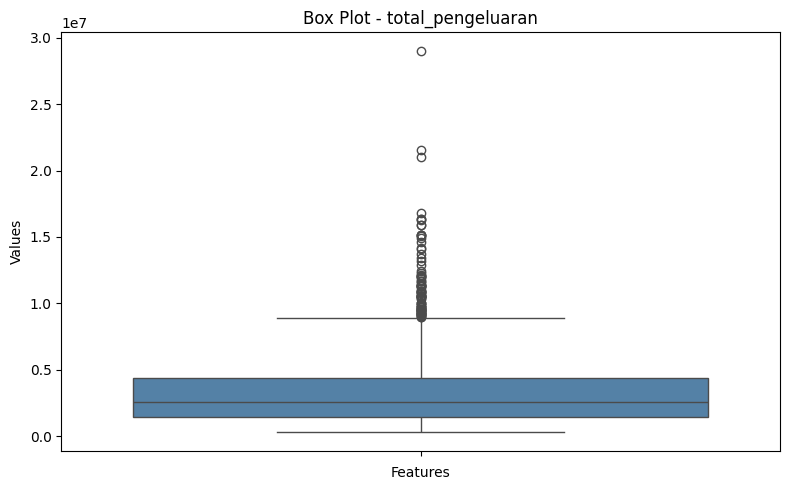

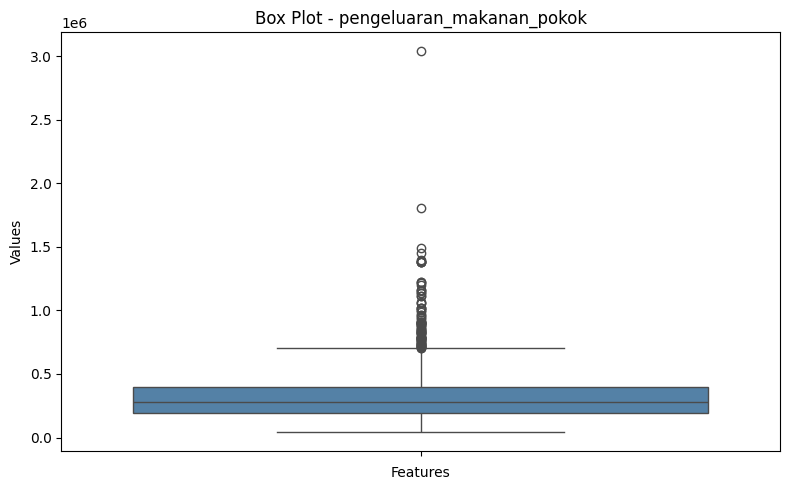

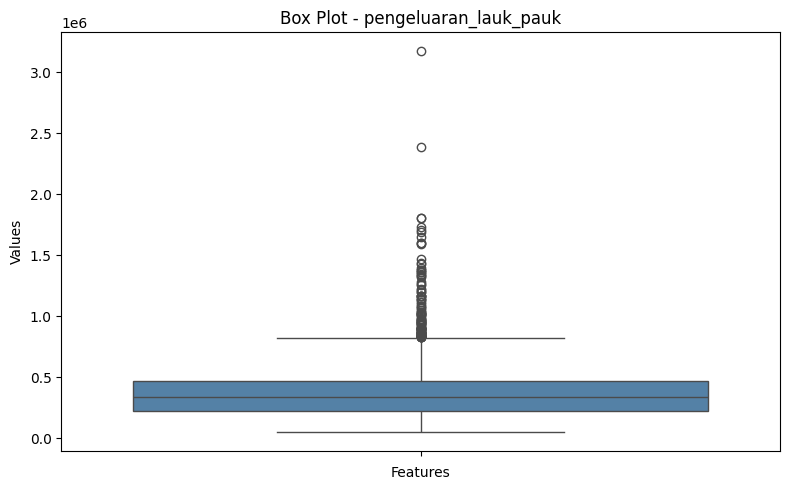

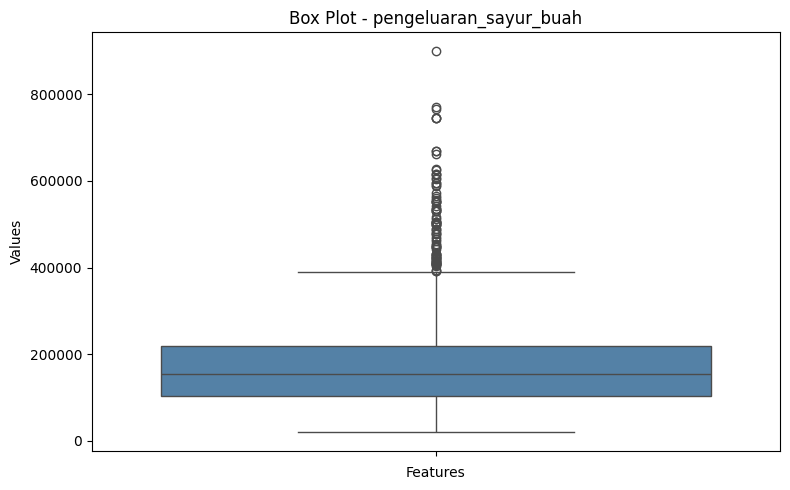

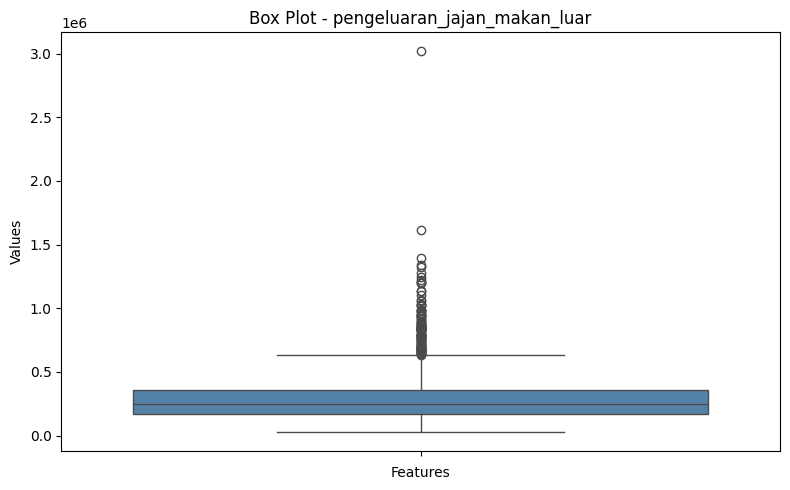

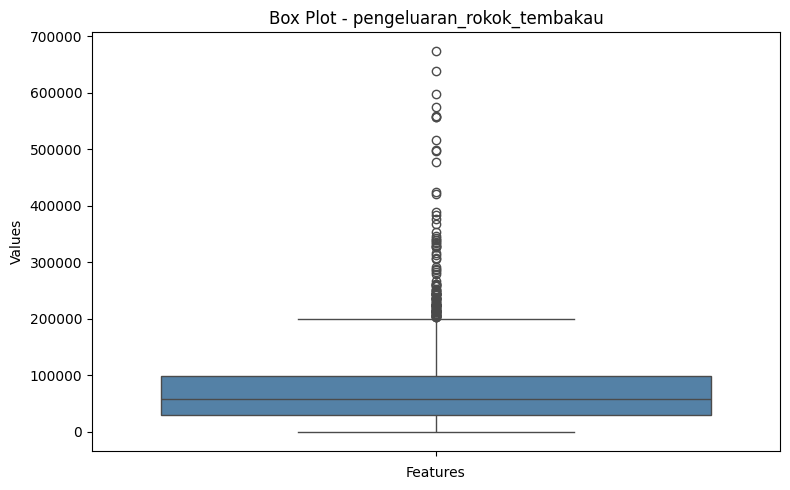

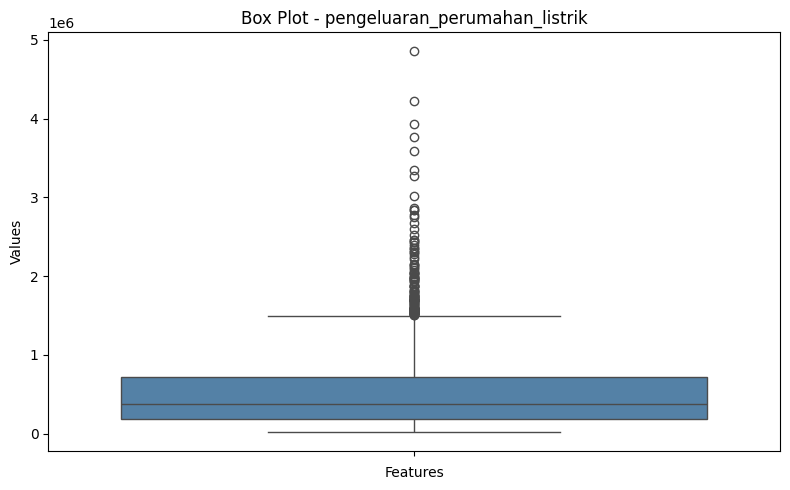

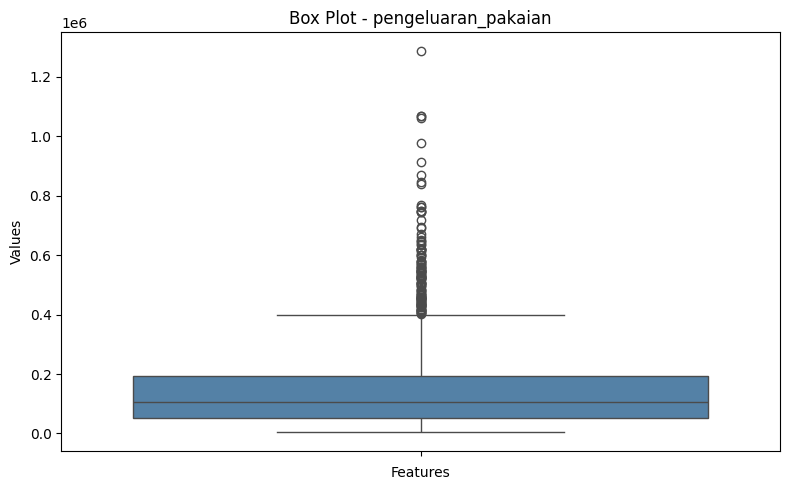

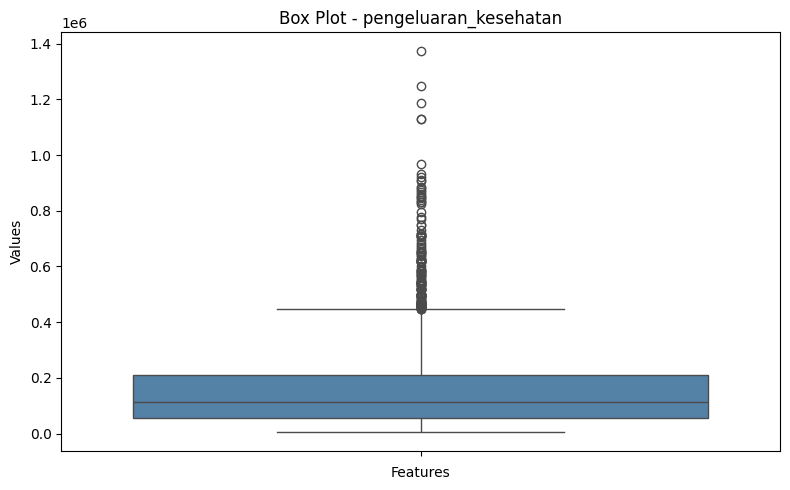

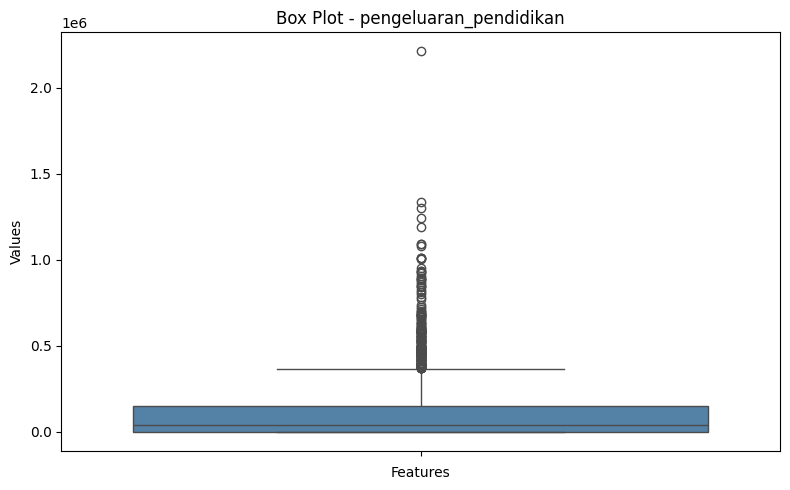

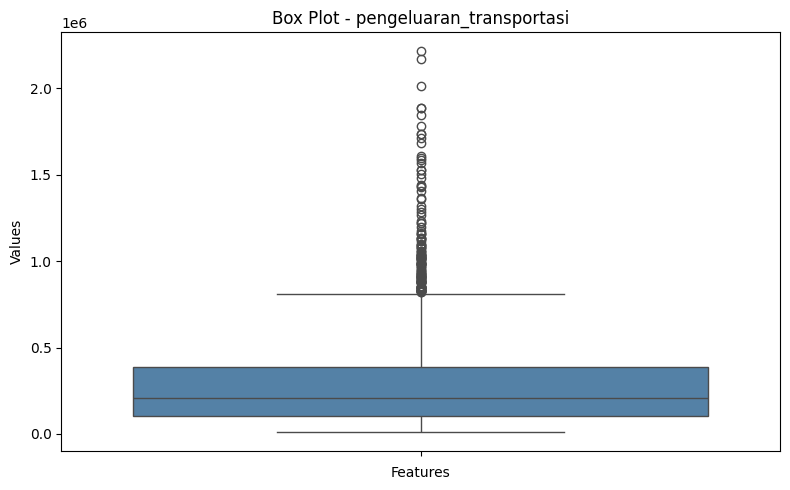

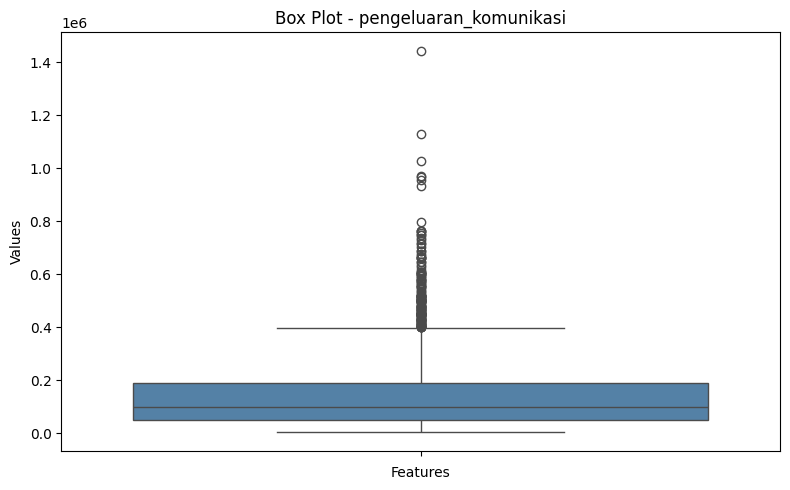

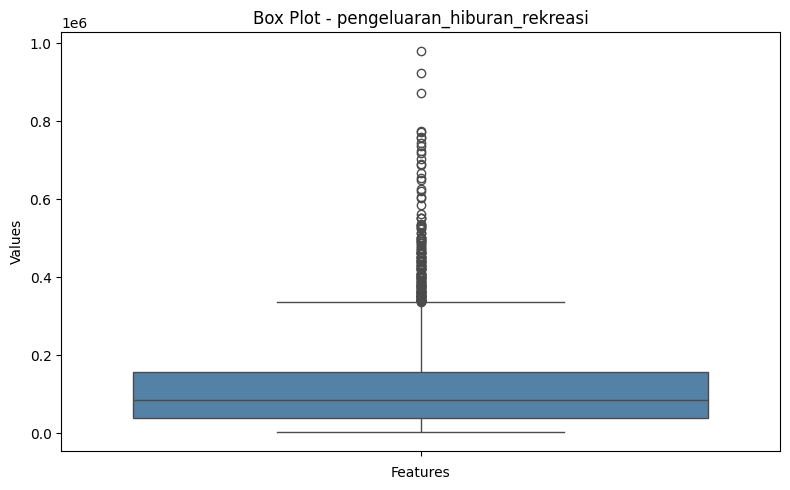

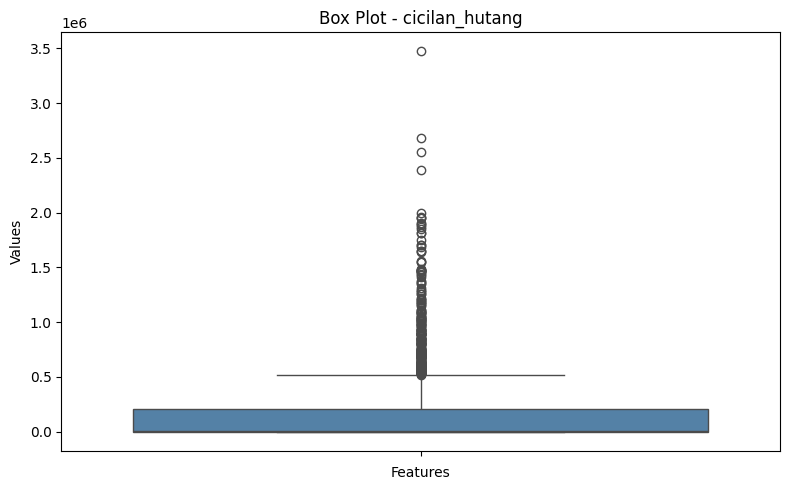

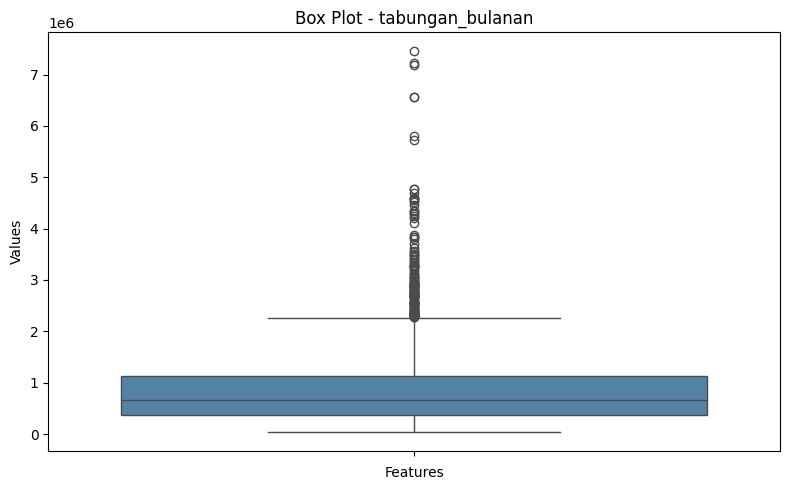

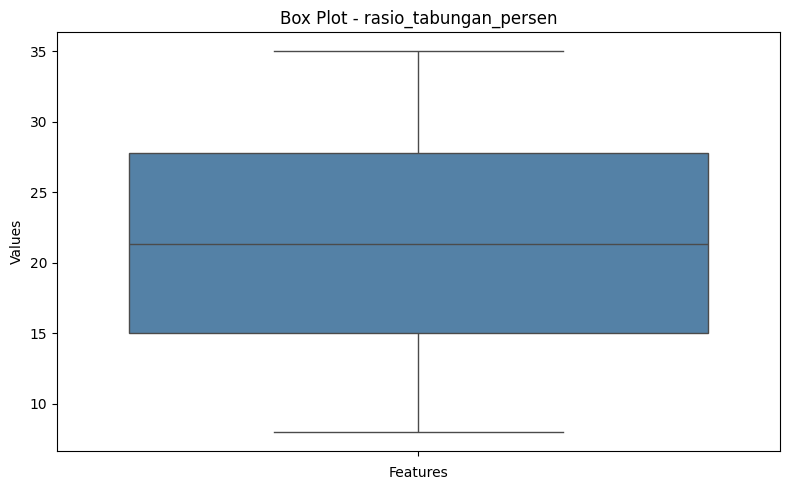

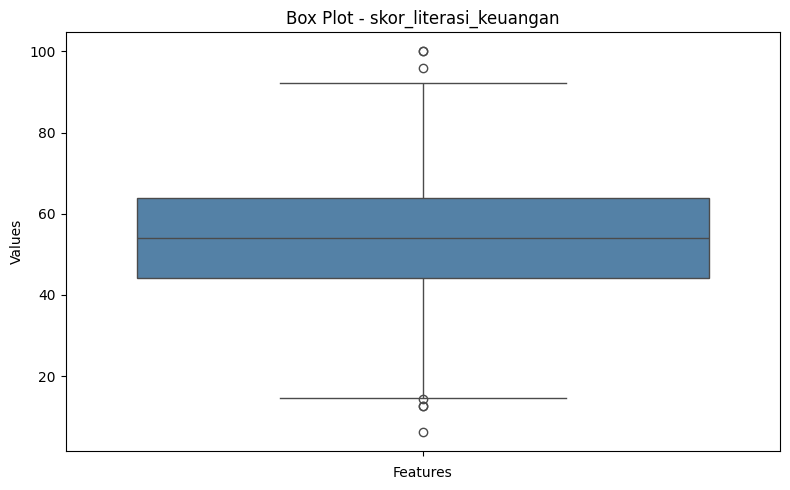

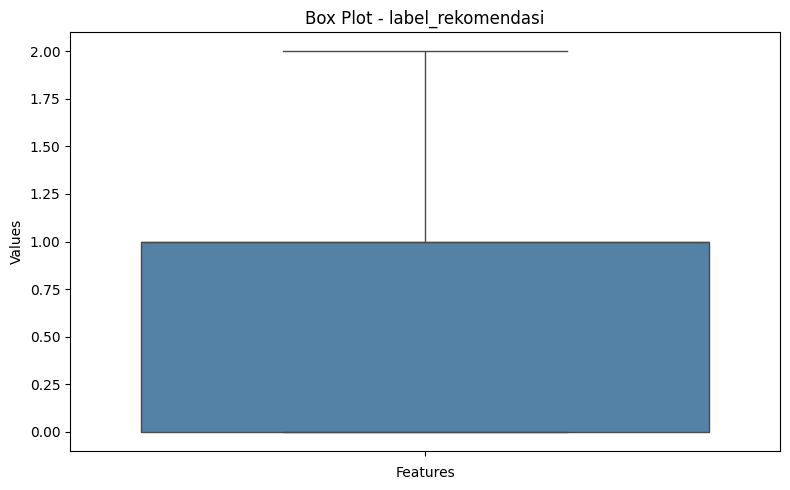

In [35]:
df_numeric = df.select_dtypes(include='number')

for column in df_numeric:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df_numeric, y=column, color='steelblue')
    plt.xlabel('Features')
    plt.ylabel('Values')
    plt.title(f'Box Plot - {column}')
    plt.tight_layout()
    plt.show()

In [36]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

condition = ~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)
df = df.loc[condition, df.columns]

In [37]:
scaler=StandardScaler()

X = df.drop(columns=['label_rekomendasi'])
y = df['label_rekomendasi']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_columns = X_train.select_dtypes(include=['int64', 'float64']).columns
X_train[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])
X_test[numeric_columns] = scaler.transform(X_test[numeric_columns])

sm = SMOTE(random_state=42)
X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)

print("Distribusi kelas setelah SMOTE:")
print(y_train_smote.value_counts())
print(f"\nTraining set : {X_train_smote.shape}")
print(f"Test set     : {X_test.shape}")

print(f"Training set shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Test set shape: X_test={X_test.shape}, y_test={y_test.shape}")

Distribusi kelas setelah SMOTE:
label_rekomendasi
1    658
2    658
0    658
Name: count, dtype: int64

Training set : (1974, 26)
Test set     : (290, 26)
Training set shape: X_train=(1158, 26), y_train=(1158,)
Test set shape: X_test=(290, 26), y_test=(290,)


In [38]:
knn = KNeighborsClassifier().fit(X_train_smote, y_train_smote)
dt = DecisionTreeClassifier().fit(X_train_smote, y_train_smote)
rf = RandomForestClassifier().fit(X_train_smote, y_train_smote)
svm = SVC().fit(X_train_smote, y_train_smote)
nb = GaussianNB().fit(X_train_smote, y_train_smote)
xgb = XGBClassifier().fit(X_train_smote, y_train_smote)
lgbm = LGBMClassifier().fit(X_train_smote, y_train_smote)

print("Selesai Training")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000907 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6104
[LightGBM] [Info] Number of data points in the train set: 1974, number of used features: 26
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [39]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    results = {
        'Confusion Matrix': cm,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, average='weighted', zero_division=0)
    }
    return results

results = {
    'K-Nearest Neighbors (KNN)': evaluate_model(knn, X_test, y_test),
    'Decision Tree (DT)': evaluate_model(dt, X_test, y_test),
    'Random Forest (RF)': evaluate_model(rf, X_test, y_test),
    'Support Vector Machine (SVM)': evaluate_model(svm, X_test, y_test),
    'Naive Bayes (NB)': evaluate_model(nb, X_test, y_test),
    'XGBoost (XGB)': evaluate_model(xgb, X_test, y_test),
    'LightGBM (LGBM)': evaluate_model(lgbm, X_test, y_test)
}


summary_df = pd.DataFrame(columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])

rows = []
for model_name, metrics in results.items():
    rows.append({
        'Model': model_name,
        'Accuracy': metrics['Accuracy'],
        'Precision': metrics['Precision'],
        'Recall': metrics['Recall'],
        'F1-Score': metrics['F1-Score']
    })

summary_df = pd.DataFrame(rows)

print(summary_df)

                          Model  Accuracy  Precision    Recall  F1-Score
0     K-Nearest Neighbors (KNN)  0.727586   0.780591  0.727586  0.744248
1            Decision Tree (DT)  0.972414   0.972827  0.972414  0.972482
2            Random Forest (RF)  0.975862   0.976567  0.975862  0.975808
3  Support Vector Machine (SVM)  0.896552   0.897892  0.896552  0.897107
4              Naive Bayes (NB)  0.893103   0.904580  0.893103  0.895862
5                 XGBoost (XGB)  0.979310   0.979266  0.979310  0.979230
6               LightGBM (LGBM)  0.975862   0.975802  0.975862  0.975818


In [40]:
from sklearn.metrics import accuracy_score

selected_model = nb
model_name = "Naive Bayes"

y_train_pred = selected_model.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)

y_test_pred = selected_model.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"--- {model_name} Model Accuracy ---")
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Gap           : {train_acc - test_acc:.4f}")

--- Naive Bayes Model Accuracy ---
Train Accuracy: 0.9007
Test Accuracy : 0.8931
Gap           : 0.0076


In [43]:
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    'n_estimators'     : [50, 100, 200],
    'max_depth'        : [10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [2],
    'max_features'     : ['sqrt', 'log2']
}

grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, cv=5, scoring='f1_weighted')
grid_search_rf.fit(X_train_smote, y_train_smote)

print("RF Best Params :", grid_search_rf.best_params_)
print("RF Best CV Accuracy  :", grid_search_rf.best_score_)

RF Best Params : {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
RF Best CV Accuracy  : 0.9858112178984266


In [44]:
best_rf = grid_search_rf.best_estimator_

train_acc = accuracy_score(y_train_smote, best_rf.predict(X_train_smote))
test_acc  = accuracy_score(y_test, best_rf.predict(X_test))

print(f"Train Accuracy : {train_acc:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Gap            : {train_acc - test_acc:.4f}")
print(f"CV Accuracy    : {grid_search_rf.best_score_:.4f}")

Train Accuracy : 0.9990
Test Accuracy  : 0.9793
Gap            : 0.0197
CV Accuracy    : 0.9858


In [45]:
import joblib
joblib.dump(best_rf, 'best_rf.h5')

['best_rf.h5']

In [46]:
joblib.dump(scaler, 'scaler.h5')

['scaler.h5']